In [60]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import random
from collections import Counter


In [61]:
df = pd.read_csv("../data/raw/dataset.csv")

print(df.shape)
print(df.head())
print(df.tail())

(1669, 3)
                     input                       target            type
0        मुझे बाहर जाना है        mujhe bahar jaana hai  hi_to_hinglish
1       तुम क्या कर रहे हो          tum kya kar rahe ho  hi_to_hinglish
2         आज मौसम अच्छा है         aaj mausam accha hai  hi_to_hinglish
3          मुझे भूख लगी है        mujhe bhookh lagi hai  hi_to_hinglish
4  क्या तुम मेरे साथ चलोगे  kya tum mere saath chalogey  hi_to_hinglish
                           input                   target            type
1664        I am going to school  main school ja rha hoon  en_to_hinglish
1665  I need to use the washroom  muje washroom jaana hai  en_to_hinglish
1666            I want to go out     muje bahar jaana hai  en_to_hinglish
1667        WiFi password please   wifi ka password do na  en_to_hinglish
1668            I can't eat this   main yeh nhi kha sakta  en_to_hinglish


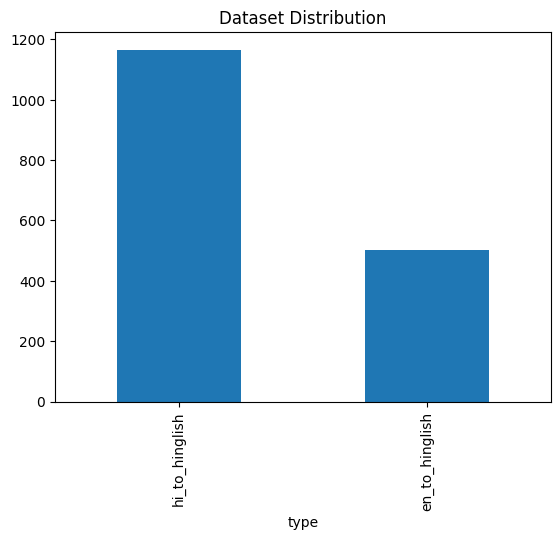

In [62]:
df['type'].value_counts().plot(kind='bar')
plt.title("Dataset Distribution")
plt.show()

In [63]:
class Tokenizer:
    def __init__(self):
        self.word2idx = {"<pad>":0, "<sos>":1, "<eos>":2, "<unk>":3}
        self.idx2word = {0:"<pad>", 1:"<sos>", 2:"<eos>", 3:"<unk>"}

    def fit(self, texts):
        counter = Counter()
        for t in texts:
            counter.update(t.split())

        for word in counter:
            idx = len(self.word2idx)
            self.word2idx[word] = idx
            self.idx2word[idx] = word

    def encode(self, text):
        return [1] + [self.word2idx.get(w, 3) for w in text.split()] + [2]

In [64]:
src_texts = df["input"].tolist()
trg_texts = df["target"].tolist()

src_tok = Tokenizer()
trg_tok = Tokenizer()

src_tok.fit(src_texts)
trg_tok.fit(trg_texts)

pairs = [(src_tok.encode(s), trg_tok.encode(t)) for s, t in zip(src_texts, trg_texts)]

In [65]:
class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hid_dim):
        super().__init__()
        self.embedding = nn.Embedding(input_dim, emb_dim)
        self.rnn = nn.LSTM(emb_dim, hid_dim, batch_first=True)

    def forward(self, x):
        embedded = self.embedding(x)
        outputs, (hidden, cell) = self.rnn(embedded)
        return outputs, hidden, cell


class Attention(nn.Module):
    def __init__(self, hid_dim):
        super().__init__()
        self.attn = nn.Linear(hid_dim*2, hid_dim)
        self.v = nn.Linear(hid_dim, 1, bias=False)

    def forward(self, hidden, encoder_outputs):
        seq_len = encoder_outputs.shape[1]
        hidden = hidden[-1].unsqueeze(1).repeat(1, seq_len, 1)
        energy = torch.tanh(self.attn(torch.cat((hidden, encoder_outputs), dim=2)))
        attention = self.v(energy).squeeze(2)
        return torch.softmax(attention, dim=1)


class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hid_dim, attention):
        super().__init__()
        self.embedding = nn.Embedding(output_dim, emb_dim)
        self.rnn = nn.LSTM(hid_dim + emb_dim, hid_dim, batch_first=True)
        self.fc = nn.Linear(hid_dim, output_dim)
        self.attention = attention

    def forward(self, x, hidden, cell, encoder_outputs):
        x = x.unsqueeze(1)
        embedded = self.embedding(x)

        attn_weights = self.attention(hidden, encoder_outputs)
        context = torch.bmm(attn_weights.unsqueeze(1), encoder_outputs)

        rnn_input = torch.cat((embedded, context), dim=2)
        output, (hidden, cell) = self.rnn(rnn_input, (hidden, cell))

        prediction = self.fc(output.squeeze(1))
        return prediction, hidden, cell, attn_weights

In [66]:
INPUT_DIM = len(src_tok.word2idx)
OUTPUT_DIM = len(trg_tok.word2idx)

encoder = Encoder(INPUT_DIM, 128, 256)
attention = Attention(256)
decoder = Decoder(OUTPUT_DIM, 128, 256, attention)

optimizer = torch.optim.Adam(list(encoder.parameters()) + list(decoder.parameters()))
criterion = nn.CrossEntropyLoss(ignore_index=0)

In [67]:
teacher_forcing_ratio = 0.7
epochs = 25

for epoch in range(epochs):
    total_loss = 0

    for src, trg in pairs:  # keep small for speed

        src_tensor = torch.tensor(src).unsqueeze(0)
        trg_tensor = torch.tensor(trg)

        encoder_outputs, hidden, cell = encoder(src_tensor)

        loss = 0

        # Start with <sos>
        input_token = trg_tensor[0].unsqueeze(0)

        for t in range(1, len(trg_tensor)):

            output, hidden, cell, _ = decoder(
                input_token, hidden, cell, encoder_outputs
            )

            # Calculate loss
            loss += criterion(output, trg_tensor[t].unsqueeze(0))

            # TEACHER FORCING LOGIC
            teacher_force = random.random() < teacher_forcing_ratio

            top1 = output.argmax(1)

            # Choose next input
            input_token = (
                trg_tensor[t].unsqueeze(0) if teacher_force else top1
            )

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.2f}")

Epoch 1, Loss: 41676.30
Epoch 2, Loss: 30071.09
Epoch 3, Loss: 20489.89
Epoch 4, Loss: 12090.02
Epoch 5, Loss: 5959.32
Epoch 6, Loss: 2767.03
Epoch 7, Loss: 1546.56
Epoch 8, Loss: 1285.29
Epoch 9, Loss: 1047.86
Epoch 10, Loss: 839.90
Epoch 11, Loss: 728.99
Epoch 12, Loss: 620.44
Epoch 13, Loss: 609.61
Epoch 14, Loss: 515.04
Epoch 15, Loss: 583.16
Epoch 16, Loss: 634.93
Epoch 17, Loss: 539.53
Epoch 18, Loss: 378.43
Epoch 19, Loss: 411.17
Epoch 20, Loss: 403.44
Epoch 21, Loss: 362.00
Epoch 22, Loss: 384.54
Epoch 23, Loss: 345.90
Epoch 24, Loss: 375.52
Epoch 25, Loss: 305.19


In [68]:
def translate(sentence):
    encoder.eval()
    decoder.eval()

    src = torch.tensor(src_tok.encode(sentence)).unsqueeze(0)

    encoder_outputs, hidden, cell = encoder(src)

    input_token = torch.tensor([1])  # <sos>
    outputs = []

    for _ in range(20):
        output, hidden, cell, attn = decoder(input_token, hidden, cell, encoder_outputs)
        pred = output.argmax(1).item()

        if pred == 2:  # <eos>
            break

        outputs.append(pred)
        input_token = torch.tensor([pred])

    return " ".join([trg_tok.idx2word[i] for i in outputs])

In [69]:
print(translate("मुझे अभी बाहर जाना है"))
print(translate("तुम क्या कर रहे हो अभी"))
print(translate("आज बहुत ज्यादा गर्मी है"))
print(translate("क्या तुम मेरे साथ आओगे"))
print(translate("मुझे थोड़ा आराम करना है"))

mujhe bahar jaana hai
tum kya kar rahe ho gaya
aaj mausam bahut suhana hai
kya tum mere saath chalogey
mujhe thoda aaram hai


In [70]:
def show_attention(sentence):
    encoder.eval()
    decoder.eval()

    src_tokens = src_tok.encode(sentence)
    src = torch.tensor(src_tokens).unsqueeze(0)

    encoder_outputs, hidden, cell = encoder(src)

    input_token = torch.tensor([1])  # <sos>
    attentions = []

    for _ in range(20):
        output, hidden, cell, attn = decoder(input_token, hidden, cell, encoder_outputs)

        pred = output.argmax(1).item()

        # FIX HERE (squeeze dimensions)
        attentions.append(attn.squeeze(0).detach().numpy())

        if pred == 2:
            break

        input_token = torch.tensor([pred])


    attn_matrix = np.array(attentions)

    plt.figure(figsize=(8, 5))
    plt.imshow(attn_matrix, cmap='viridis')
    plt.colorbar()

    plt.title("Attention Heatmap")

    
    plt.xlabel("Input Words")
    plt.ylabel("Output Steps")

    plt.xticks(range(len(src_tokens)), src_tok.encode(sentence))
    
    plt.show()

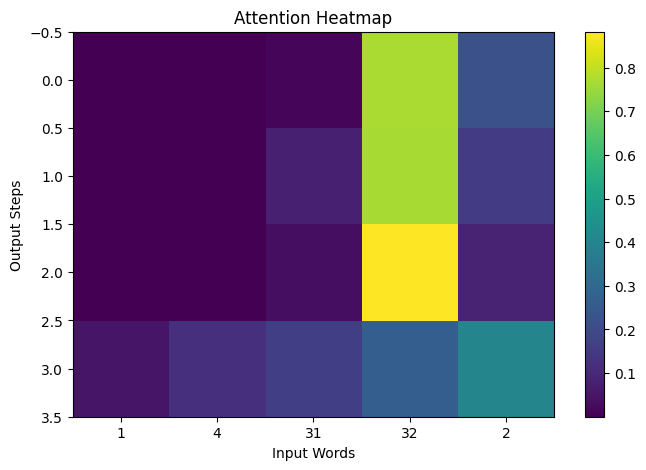

'mujhe paani chahiye'

In [71]:
show_attention("मुझे पानी चाहिए")
translate("मुझे पानी चाहिए")

In [72]:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

In [73]:
def compute_bleu(reference, prediction):
    smoothie = SmoothingFunction().method4
    return sentence_bleu([reference.split()], prediction.split(), smoothing_function=smoothie)

In [74]:
scores = []

samples = df.sample(50)  # evaluate on 50 samples

for _, row in samples.iterrows():
    inp = row["input"]
    true = row["target"]

    pred = translate(inp)

    score = compute_bleu(true, pred)
    scores.append(score)

print("Average BLEU Score:", sum(scores)/len(scores))

Average BLEU Score: 0.7658014810446048


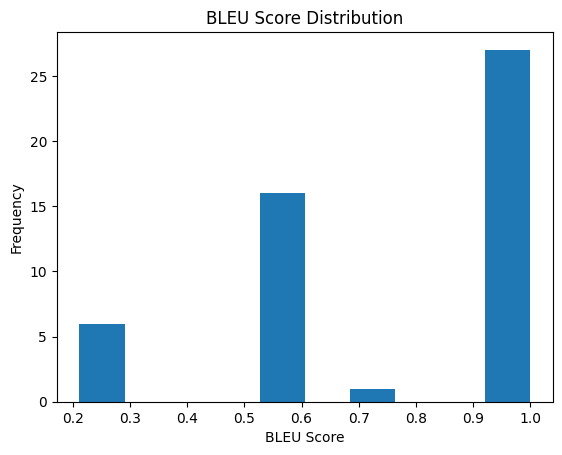

In [75]:
plt.hist(scores, bins=10)
plt.title("BLEU Score Distribution")
plt.xlabel("BLEU Score")
plt.ylabel("Frequency")
plt.show()

In [78]:
results = []

for _, row in samples.head(20).iterrows():
    inp = row["input"]
    true = row["target"]
    pred = translate(inp)

    results.append([inp, true, pred])

results_df = pd.DataFrame(results, columns=["Input", "Actual", "Predicted"])
results_df

,Input,Actual,Predicted
0,सुबह कॉल करना।,subah call karna.,subah call karna.
1,"शुक्रिया, मदद के लिए।","shukriya, madad ke liye.","shukriya, madad ke liye."
2,रिमोट कहाँ है?,remote kahan hai?,remote kahan h?
3,ज्यादा चाय मत पीना।,zyada chai mat peena.,zyada chai mat peena.
4,I am feeling better,ab thoda better feel kar rha hoon,ab thoda better feel kar rha hoon
5,UPI payment,upi se payment kar do,upi se payment kar do
6,नया टूथपेस्ट लाना,naya toothpaste laana,naya toothpaste laana
7,स्पीड कम रखना।,speed kam rakhna.,speed kam rakhna.
8,बहुत एंजॉय किया,bahut enjoy kiya,bahut enjoy kiya
9,डेज़र्ट में क्या है?,dessert mein kya hai?,dessert mein kya hai?


In [79]:
print(translate("मुझे पानी चाहिए"))
print(translate("तुम कहाँ हो"))
print(translate("मैं थक गया हूँ"))
print(translate("जल्दी आओ"))
print(translate("मुझे नींद आ रही है"))

mujhe paani chahiye
tum kahan ho
main thak gaya hoon
jaldi aao
mujhe neend aa rahi hai


In [80]:
print(translate("मुझे अभी बाहर जाना है"))
print(translate("तुम अभी क्या कर रहे हो"))
print(translate("आज मौसम बहुत अच्छा है"))
print(translate("क्या तुम मेरे साथ चलोगे"))
print(translate("मुझे थोड़ा आराम करना है"))

mujhe bahar jaana hai
tum kya kar rahe ho kya?
aaj mausam bahut accha hai
kya tum mere saath chalogey
mujhe thoda aaram hai


In [81]:
print(translate("मुझे ठंडा पानी अभी चाहिए"))
print(translate("तुम इतने देर से क्यों आए"))
print(translate("आज बहुत ज्यादा ट्रैफिक था"))
print(translate("क्या तुमने खाना खा लिया"))
print(translate("मैं तुम्हें बाद में कॉल करूँगा"))

mujhe paani chahiye mujhe hn
weight mein jagah se baat raha
aaj office bahut suhana hai
chai mein kya leke rakho.
main sunne ke mein time dene


In [82]:
print(translate("भाई जल्दी आओ, मैं इंतजार कर रहा हूँ"))
print(translate("मुझे अभी ऑफिस के लिए निकलना है"))
print(translate("तुम कहाँ हो, कॉल क्यों नहीं उठा रहे"))
print(translate("आज बहुत थकान लग रही है"))
print(translate("चलो बाहर कुछ खाने चलते हैं"))

subah jaldi kar raha raha hoon
mujhe thodi madad ke liye thank you
kitchen kahan clear kahan kar rahe ho
aaj mausam bahut accha hai
aaj office se kitne baje hain.


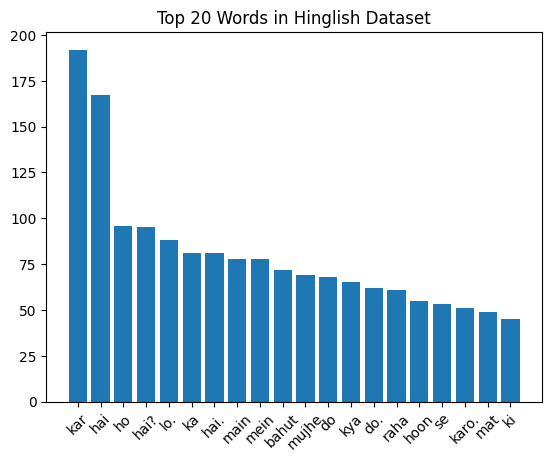

In [83]:
from collections import Counter

all_words = " ".join(df["target"]).split()
word_freq = Counter(all_words)

common_words = dict(word_freq.most_common(20))

plt.bar(common_words.keys(), common_words.values())
plt.xticks(rotation=45)
plt.title("Top 20 Words in Hinglish Dataset")
plt.show()

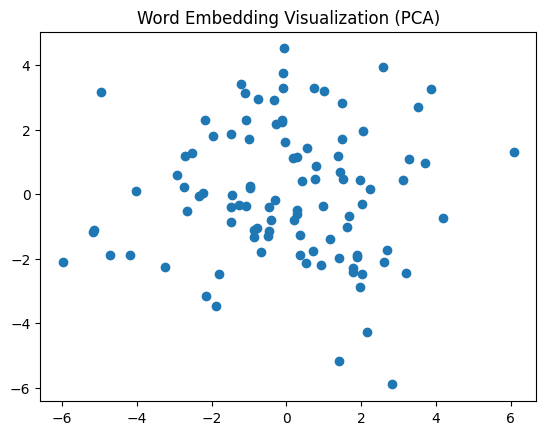

In [84]:
from sklearn.decomposition import PCA

embeddings = encoder.embedding.weight.detach().numpy()

pca = PCA(n_components=2)
reduced = pca.fit_transform(embeddings[:100])

plt.scatter(reduced[:,0], reduced[:,1])
plt.title("Word Embedding Visualization (PCA)")
plt.show()